<h1 align="center">Manejo y preprocesamiento de datos</h1>
<h1 align="center">Entregable #2</h1>
<h3 align="center">Santiago Correa Marulanda</h3>
<h3 align="center">UdeA</h3>


**Contexto**
En el analisis anterior sobre EDA y detección de datos atípicos se llegó a ciertas conclusiones que serán las herramientas en este notebook para 

Importar librerias

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import skew, kurtosis, chi2_contingency
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

Lectura de los datos

In [112]:
try:
    earthq = pd.read_csv("../datos/Earthquakes_South_Asia.csv")
    print(f"Se han leido los datos")
except:
    print("ERROR: No se leyeron los datos")

Se han leido los datos


Vista rápida de los datos

In [113]:
pd.set_option("display.max_columns", None) # Visualizar todas las columnas
earthq.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1904-08-30T11:43:20.850Z,30.684,100.608,15.0,7.09,mw,NaN,NaN,NaN,NaN,iscgem,iscgem16957826,2022-04-25T20:23:00.657Z,"150 km WNW of Kangding, China",earthquake,NaN,25.0,0.40,NaN,reviewed,iscgem,iscgem
1,1905-02-17T11:41:07.820Z,23.689,97.170,15.0,7.26,mw,NaN,NaN,NaN,NaN,iscgem,iscgem16957836,2022-04-25T20:23:21.748Z,"62 km S of Bhamo, Myanmar",earthquake,NaN,25.0,0.37,NaN,reviewed,iscgem,iscgem
2,1905-04-04T00:49:59.230Z,32.597,76.916,20.0,7.90,mw,NaN,NaN,NaN,NaN,iscgem,iscgem16957848,2022-04-25T20:23:47.590Z,"10 km WNW of Kyelang, India",earthquake,NaN,25.0,0.40,NaN,reviewed,iscgem,iscgem
3,1905-05-31T18:23:32.750Z,18.895,120.203,15.0,6.80,mw,NaN,NaN,NaN,NaN,iscgem,iscgem610548604,2022-04-25T20:39:25.950Z,"61 km NW of Davila, Philippines",earthquake,NaN,5.0,0.46,NaN,reviewed,iscgem,iscgem
4,1905-06-02T05:39:39.600Z,33.715,131.759,60.0,6.91,mw,NaN,NaN,NaN,NaN,iscgem,iscgem16957852,2022-04-25T20:23:58.797Z,"31 km SSW of Hikari, Japan",earthquake,NaN,15.4,0.53,NaN,reviewed,iscgem,iscgem


In [114]:
earthq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102134 entries, 0 to 102133
Data columns (total 22 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   time             102134 non-null  object 
 1   latitude         102134 non-null  float64
 2   longitude        102134 non-null  float64
 3   depth            102134 non-null  float64
 4   mag              102134 non-null  float64
 5   magType          102134 non-null  object 
 6   nst              44321 non-null   float64
 7   gap              61683 non-null   float64
 8   dmin             30173 non-null   float64
 9   rms              92654 non-null   float64
 10  net              102134 non-null  object 
 11  id               102134 non-null  object 
 12  updated          102134 non-null  object 
 13  place            102134 non-null  object 
 14  type             102134 non-null  object 
 15  horizontalError  27423 non-null   float64
 16  depthError       55742 non-null   floa

In [115]:
earthq.describe(include="all")

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
count,102134,102134.000000,102134.000000,102134.000000,102134.000000,102134,44321.000000,61683.000000,30173.000000,92654.000000,102134,102134,102134,102134,102134,27423.000000,55742.000000,33222.000000,84644.000000,102134,102134,102134
unique,102134,NaN,NaN,NaN,NaN,13,NaN,NaN,NaN,NaN,5,102134,86118,59381,3,NaN,NaN,NaN,NaN,2,14,24
top,2024-11-14T02:38:16.141Z,NaN,NaN,NaN,NaN,mb,NaN,NaN,NaN,NaN,us,us7000nrn9,2024-02-06T21:54:01.040Z,"Nicobar Islands, India region",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
freq,1,NaN,NaN,NaN,NaN,88844,NaN,NaN,NaN,NaN,98874,1,55,1025,102101,NaN,NaN,NaN,NaN,102129,98546,92686
mean,NaN,18.449853,106.247929,59.483604,4.560348,NaN,46.302498,112.036942,2.795344,0.908260,NaN,NaN,NaN,NaN,NaN,7.883577,9.071499,0.141041,18.759569,NaN,NaN,NaN
std,NaN,13.615392,21.880469,77.597673,0.540563,NaN,61.412490,48.965703,3.103738,0.273452,NaN,NaN,NaN,NaN,NaN,2.792829,8.599259,0.090126,28.648616,NaN,NaN,NaN
min,NaN,0.000000,60.001000,0.000000,3.000000,NaN,3.000000,9.000000,0.001000,0.000000,NaN,NaN,NaN,NaN,NaN,0.810000,0.000000,0.000000,1.000000,NaN,NaN,NaN
25%,NaN,5.162625,91.839100,19.120750,4.200000,NaN,15.000000,76.100000,1.117000,0.720000,NaN,NaN,NaN,NaN,NaN,6.100000,3.600000,0.083000,4.000000,NaN,NaN,NaN
50%,NaN,17.420150,120.365500,33.000000,4.500000,NaN,26.000000,107.400000,1.968000,0.900000,NaN,NaN,NaN,NaN,NaN,7.630000,7.000000,0.123000,10.000000,NaN,NaN,NaN
75%,NaN,30.714675,126.158000,64.300000,4.800000,NaN,51.000000,141.000000,3.221000,1.100000,NaN,NaN,NaN,NaN,NaN,9.500000,11.000000,0.173000,21.000000,NaN,NaN,NaN


Volveremos a seleccionar los datos categoricos y numericos del analisis anterior (Notebook 01)

In [116]:
# Obtenemos las variables numericas y categoricas por separado
col_num = earthq.select_dtypes(include=["Float64"])
col_cat = earthq.select_dtypes(include=["object"])

print(f"\tVariables numericas:\n{col_num.columns}")
print(f"\n\tVariables categoricas:\n{col_cat.columns}")

num = col_num[["latitude", "longitude", "depth", "mag", "rms"]]
cat = col_cat[["time","magType", "type", "status"]]

print(f"\n\n\t\t  Nos quedaremos con las siguientes:")
print()
print("==============================================================================")
print(f"\n\n\t\t\tVariables numericas:\n{num.columns}")
print(f"\n\n\t\t\tVariables categoricas:\n{cat.columns}")

	Variables numericas:
Index(['latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'dmin', 'rms',
       'horizontalError', 'depthError', 'magError', 'magNst'],
      dtype='object')

	Variables categoricas:
Index(['time', 'magType', 'net', 'id', 'updated', 'place', 'type', 'status',
       'locationSource', 'magSource'],
      dtype='object')


		  Nos quedaremos con las siguientes:



			Variables numericas:
Index(['latitude', 'longitude', 'depth', 'mag', 'rms'], dtype='object')


			Variables categoricas:
Index(['time', 'magType', 'type', 'status'], dtype='object')


Observemos los datos faltantes que hay en los datos

In [117]:
# faltantes numericas
cont_faltantes_num = num.isna().sum()
faltantes_porcentaje_num = cont_faltantes_num / len(num)

tabla_faltantes_num = pd.DataFrame({"faltantes": cont_faltantes_num,"porcentaje": (faltantes_porcentaje_num * 100).round(2)}).sort_values("porcentaje", ascending=False)
tabla_faltantes_num

,faltantes,porcentaje
rms,9480,9.28
latitude,0,0.00
longitude,0,0.00
depth,0,0.00
mag,0,0.00


In [118]:
# faltantes categoricas
cont_faltantes_cat = cat.isna().sum()
faltantes_porcentaje_cat = cont_faltantes_cat / len(cat)

tabla_faltantes_cat = pd.DataFrame({"faltantes": cont_faltantes_cat,"porcentaje": (faltantes_porcentaje_cat * 100).round(2)}).sort_values("porcentaje", ascending=False)
tabla_faltantes_cat

,faltantes,porcentaje
time,0,0.0
magType,0,0.0
type,0,0.0
status,0,0.0


Observe como de las variables seleccionadas solo una de estas (rms) tiene datos faltantes y en un porcentaje no muy grande, a aunque no despreciable. Podemos hacer imputación por la mediana o por medio de algun algoritmo de machine learning, para decidir, lo mejor es realizar una comparación de que sucedería en ambos casos para estudiar cual es aquella que menos cambia la distribución de los datos.

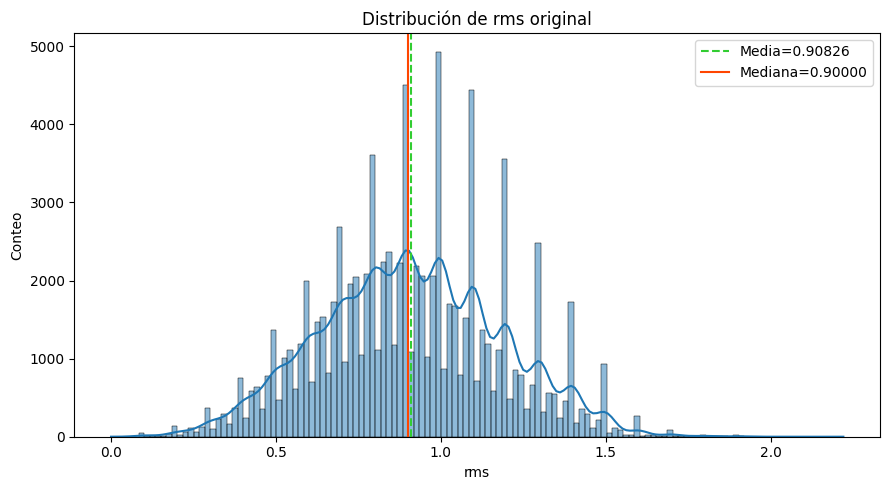

In [119]:
media_rms = num["rms"].mean()
mediana_rms = num["rms"].median()
plt.figure(figsize=(9,5))
sns.histplot(data = num, x="rms", kde=True)
plt.axvline(x = media_rms, color = "limegreen", label = f"Media={media_rms:.5f}", linestyle="--")
plt.axvline(x = mediana_rms, color = "orangered", label = f"Mediana={mediana_rms:.5f}")
plt.title("Distribución de rms original")
plt.xlabel("rms")
plt.ylabel("Conteo")
plt.legend()
plt.tight_layout()
plt.show()

#### Aplicar las imputaciones

Se aplica la mediana al ser la mas simple, Random Forest Regressor y KNN por ser los más populares para esta técnica

In [120]:
# una copia para la imputacion por la mediana
num_mediana = num.copy()
# Rellenar nan con mediana
num_mediana["rms"] = num_mediana["rms"].fillna(mediana_rms)

In [121]:
# Copia
num_rf = num.copy()

#separamos filas que queremos predecir y aquellas predictoras
df_train = num_rf[num_rf["rms"].notna()].copy()
df_pred  = num_rf[num_rf["rms"].isna()].copy()

# columnas excepto la objetivo
columnas = ["latitude", "longitude", "depth", "mag"]

# matriz caracteristicas y objetivo
X = df_train[columnas]
y = df_train["rms"]

X_pred = df_pred[columnas]

# split para evaluar el omdelo
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

rf = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

# evaluacion
y_val_pred = rf.predict(X_val)
print("MAE validación:", mean_absolute_error(y_val, y_val_pred))
print("R^2 validación:", r2_score(y_val, y_val_pred))

# usar el mismo modelo para imputar
rms_pred = rf.predict(X_pred)

# Rellenar en num_rf
num_rf.loc[num_rf["rms"].isna(), "rms"] = rms_pred


MAE validación: 0.2055744104473585
R^2 validación: 0.10067052140564048


In [122]:
# Copia
num_knn = num.copy()

# separamos filas que queremos predecir y aquellas predictoras
df_train = num_knn[num_knn["rms"].notna()].copy()
df_pred  = num_knn[num_knn["rms"].isna()].copy()

# columnas excepto la objetivo
columnas = ["latitude", "longitude", "depth", "mag"]

# matriz características y objetivo
X = df_train[columnas]
y = df_train["rms"]

X_pred = df_pred[columnas]

# split para evaluar el modelo
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

# Modelo KNN
knn = KNeighborsRegressor(n_neighbors=5,weights="distance" )

knn.fit(X_train, y_train)

# evaluación
y_val_pred = knn.predict(X_val)
print("MAE validación:", mean_absolute_error(y_val, y_val_pred))
print("R^2 validación:", r2_score(y_val, y_val_pred))

# usar el mismo modelo para imputar
rms_pred_knn = knn.predict(X_pred)

# Rellenar en num_knn
num_knn.loc[num_knn["rms"].isna(), "rms"] = rms_pred_knn


MAE validación: 0.21755940617871267
R^2 validación: -0.0037185490430111656


In [123]:
# Copias del dataset original con cada estrategia de imputación

earthq_mediana = earthq.copy()
earthq_mediana["rms"] = num_mediana["rms"]

earthq_rf = earthq.copy()
earthq_rf["rms"] = num_rf["rms"]

earthq_knn = earthq.copy()
earthq_knn["rms"] = num_knn["rms"]



**Ahora comprobemos como cambiaron las distribuciones**

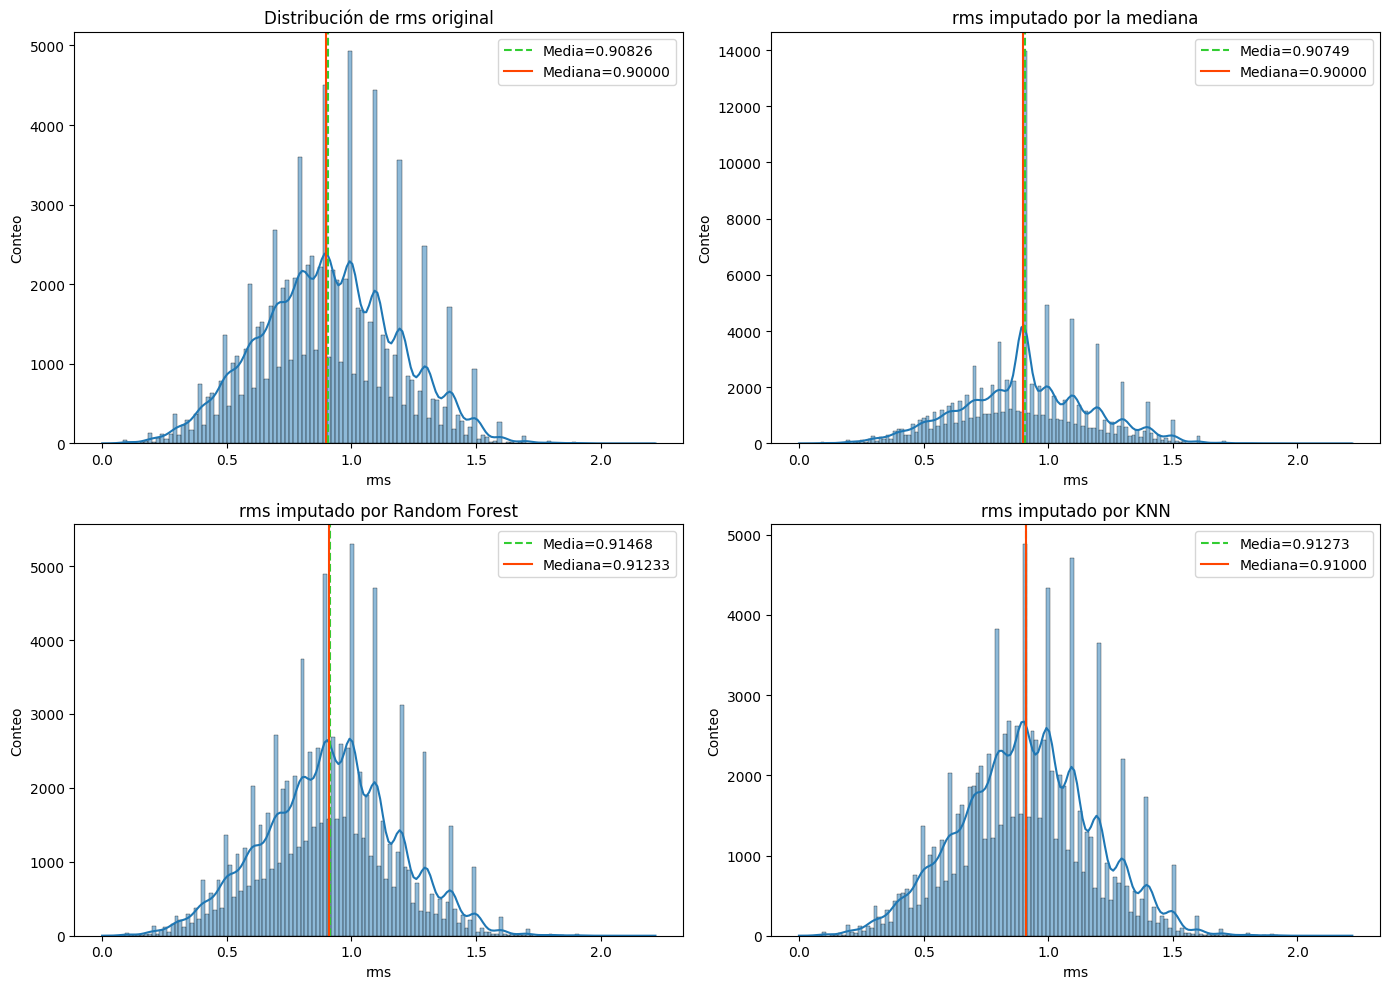

In [124]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#riginal
ax = axes[0, 0]
media_orig   = num["rms"].mean()
mediana_orig = num["rms"].median()

sns.histplot(data=num, x="rms", kde=True, ax=ax)
ax.axvline(x=media_orig,   linestyle="--", color="limegreen",label=f"Media={media_orig:.5f}")
ax.axvline(x=mediana_orig, linestyle="-",  color="orangered",label=f"Mediana={mediana_orig:.5f}")
ax.set_title("Distribución de rms original")
ax.set_xlabel("rms")
ax.set_ylabel("Conteo")
ax.legend()

# mediana
ax = axes[0, 1]
media_mediana   = earthq_mediana["rms"].mean()
mediana_mediana = earthq_mediana["rms"].median()

sns.histplot(data=earthq_mediana, x="rms", kde=True, ax=ax)
ax.axvline(x=media_mediana,   linestyle="--", color="limegreen",label=f"Media={media_mediana:.5f}")
ax.axvline(x=mediana_mediana, linestyle="-",  color="orangered",label=f"Mediana={mediana_mediana:.5f}")
ax.set_title("rms imputado por la mediana")
ax.set_xlabel("rms")
ax.set_ylabel("Conteo")
ax.legend()

#Random Forest
ax = axes[1, 0]
media_rf   = earthq_rf["rms"].mean()
mediana_rf = earthq_rf["rms"].median()

sns.histplot(data=earthq_rf, x="rms", kde=True, ax=ax)
ax.axvline(x=media_rf,   linestyle="--", color="limegreen",label=f"Media={media_rf:.5f}")
ax.axvline(x=mediana_rf, linestyle="-",  color="orangered",label=f"Mediana={mediana_rf:.5f}")
ax.set_title("rms imputado por Random Forest")
ax.set_xlabel("rms")
ax.set_ylabel("Conteo")
ax.legend()

# KNN
ax = axes[1, 1]
media_knn = earthq_knn["rms"].mean()
mediana_knn = earthq_knn["rms"].median()

sns.histplot(data=earthq_knn, x="rms", kde=True, ax=ax)
ax.axvline(x=media_knn,   linestyle="--", color="limegreen",label=f"Media={media_knn:.5f}")
ax.axvline(x=mediana_knn, linestyle="-",  color="orangered",label=f"Mediana={mediana_knn:.5f}")
ax.set_title("rms imputado por KNN")
ax.set_xlabel("rms")
ax.set_ylabel("Conteo")
ax.legend()

plt.tight_layout()
plt.show()


La imputacion por la mediana modifica mucho la distribucion de los datos, mientras que Random Forest Regressor no tanto y además tiene mejores métricas que KNN, por lo que tomaremos esta opción

In [125]:
data_imputed = earthq.copy()
data_imputed["rms"] = num_rf["rms"]
print(f'NAN en rms (original): {earthq["rms"].isna().sum()}')
print(f'NAN en rms (data_imputed): {data_imputed["rms"].isna().sum()}')

NAN en rms (original): 9480
NAN en rms (data_imputed): 0


### Manejo de atípicos

Recordemos que habiamos detectado atípicos para magnitud y rms por medio de Z-Score y profundidad con ayuda de Isolation Forest

In [126]:
# redefinir num a partir de data_imputed
num = data_imputed[["latitude", "longitude", "depth", "mag", "rms"]].copy()

In [127]:
# usamos solo depth para Isolation Forest
X_depth = num[["depth"]] 

# Definimos el modelo
iso_depth = IsolationForest(n_estimators=200,contamination=0.01,random_state=0)

#entrenar el modelo
iso_depth.fit(X_depth)

# predicción: 1 = normal y -1 = outlier
pred_iso = iso_depth.predict(X_depth)

#columna booleana de outliers en depth
data_imputed["outlier_depth_iso"] = pred_iso == -1

# Resumen
total_obs = len(data_imputed)
n_outliers = data_imputed["outlier_depth_iso"].sum()
porc_outliers = n_outliers / total_obs * 100

print(f"Total de observaciones: {total_obs}")
print(f"Outliers en depth (IsolationForest): {n_outliers} ({porc_outliers:.3f}%)")


Total de observaciones: 102134
Outliers en depth (IsolationForest): 1009 (0.988%)


In [128]:
# Tamaño antes
print("Filas antes de eliminar outliers de depth:", len(data_imputed))

#eliminar filas donde outlier_depth_iso es true
data_imputed = data_imputed[data_imputed["outlier_depth_iso"] == False].copy()

# Tamaño despues
print("Filas despues de eliminar outliers de depth:", len(data_imputed))

Filas antes de eliminar outliers de depth: 102134
Filas despues de eliminar outliers de depth: 101125


In [129]:
# Verifiquemos el tamaño antes de eliminar
print("Filas antes de eliminar atipicos mag/rms:", len(data_imputed))

# Eliminamos segun los umbrales que concluimos en el notebook anterior
mask_out_mag = (data_imputed["mag"] < 2.94) | (data_imputed["mag"] > 6.18)
mask_out_rms = (data_imputed["rms"] < 0.09) | (data_imputed["rms"] > 1.73)

# conteos antes de eliminar
n_out_mag = mask_out_mag.sum()
n_out_rms = mask_out_rms.sum()
print(f"Atipicos en mag: {n_out_mag}")
print(f"Atipicos en rms: {n_out_rms}")

# Mascara combinada: outlier si lo es en mag O en rms
mask_out_any = mask_out_mag | mask_out_rms
n_out_any = mask_out_any.sum()

print(f"Filas que son atipicas en mag o rms: {n_out_any}")

# eliminar esas filas de data_imputed
data_imputed = data_imputed[~mask_out_any].copy()

print("Filas despues de eliminar atipicos mag/rms:", len(data_imputed))


Filas antes de eliminar atipicos mag/rms: 101125
Atipicos en mag: 1496
Atipicos en rms: 94
Filas que son atipicas en mag o rms: 1590
Filas despues de eliminar atipicos mag/rms: 99535


Al finalizar el manejo de atípicos, hemos eliminado aproximadamente un 3% de los datos

In [130]:
# nuevo dataset para saber que aqui tenemos loos datos sin outliers
data_no_out=data_imputed

**Demos otro pequeño vistazo a los datos**

In [131]:
data_no_out.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,outlier_depth_iso
5,1905-07-16T18:46:55.430Z,9.386,124.030,35.0,6.06,mw,NaN,NaN,NaN,0.98925,iscgemsup,iscgemsup610548608,2022-05-09T15:23:06.117Z,"25 km SSE of Alburquerque, Philippines",earthquake,NaN,32.0,0.51,NaN,reviewed,iscgemsup,iscgemsup,False
11,1906-03-26T03:28:39.050Z,22.364,121.603,15.0,6.13,mw,NaN,NaN,NaN,1.01580,iscgem,iscgem16957892,2022-04-25T20:24:48.223Z,"97 km ENE of Hengchun, Taiwan",earthquake,NaN,12.3,0.20,NaN,reviewed,iscgem,iscgem,False
15,1906-05-04T23:09:07.460Z,34.093,134.891,35.0,6.01,mw,NaN,NaN,NaN,0.76400,iscgem,iscgem610326312,2022-04-25T20:36:51.971Z,"24 km SE of Fukura, Japan",earthquake,NaN,6.2,0.53,NaN,reviewed,iscgem,iscgem,False
17,1906-06-10T20:49:34.160Z,14.224,93.087,35.0,5.75,mw,NaN,NaN,NaN,0.90925,iscgemsup,iscgemsup610548643,2022-05-09T15:24:27.786Z,"282 km N of Bamboo Flat, India",earthquake,NaN,4.4,0.67,NaN,reviewed,iscgemsup,iscgemsup,False
29,1907-01-10T05:41:03.810Z,37.157,119.999,10.0,6.18,mw,NaN,NaN,NaN,1.03355,iscgemsup,iscgemsup610548676,2022-05-09T15:24:57.163Z,"5 km ESE of Laizhou, China",earthquake,NaN,25.0,0.25,NaN,reviewed,iscgemsup,iscgemsup,False


In [132]:
data_no_out.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99535 entries, 5 to 102133
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   time               99535 non-null  object 
 1   latitude           99535 non-null  float64
 2   longitude          99535 non-null  float64
 3   depth              99535 non-null  float64
 4   mag                99535 non-null  float64
 5   magType            99535 non-null  object 
 6   nst                43655 non-null  float64
 7   gap                60731 non-null  float64
 8   dmin               29696 non-null  float64
 9   rms                99535 non-null  float64
 10  net                99535 non-null  object 
 11  id                 99535 non-null  object 
 12  updated            99535 non-null  object 
 13  place              99535 non-null  object 
 14  type               99535 non-null  object 
 15  horizontalError    26993 non-null  float64
 16  depthError         53862 n

### Transormar variables

**De las conclusiones en el EDA** recordemos que magType abarcaba varios formas de medir magnitudes en sismos, donde algunas de estas tenian similitud entre si o sus metodos se derivaban de las otras, por lo que se habló de juntar o transformar estas.

In [133]:
def agrupar_magtype(mt):
    if pd.isna(mt):
        return np.nan
    mt_low = mt.lower()
    if mt_low.startswith("mw"):
        return "Mw"
    if mt_low.startswith("mb"):
        return "Mb"
    if mt_low.startswith("ms"):
        return "Ms"
    if mt_low.startswith("ml") or mt_low.startswith("md"):
        return "Ml/Md"
    return "Otro"

In [134]:
data_cleaned = data_no_out

In [135]:
len(data_cleaned.columns)

23

In [136]:
# para agrupar
data_cleaned["magType_group"] = data_cleaned["magType"].apply(agrupar_magtype)
# eliminar magType
data_cleaned.drop(columns=["magType"], inplace=True)
len(data_cleaned.columns)


# quedarse solo con terremotos
mask_eq = data_cleaned["type"].str.lower() == "earthquake"
data_cleaned = data_cleaned[mask_eq].copy()
# ya no es necesaria la variable de type si unicamente tenemos terremotos
data_cleaned.drop(columns=["type"], inplace=True)


En cuanto a status practicamente no hay datos "automatic", asi que serán eliminados

In [137]:
data_cleaned["status_bin"] = (data_cleaned["status"] != "automatic").astype(int)
# 1 = revisado, 0 = automatico
data_cleaned.drop(columns=["status"], inplace=True)

Y para time, la separaremos en año, mes y hora (year, month, hour)

In [138]:

data_cleaned["time"] = pd.to_datetime(data_cleaned["time"], errors="coerce")

data_cleaned["year"] = data_cleaned["time"].dt.year
data_cleaned["month"] = data_cleaned["time"].dt.month
data_cleaned["hour"] = data_cleaned["time"].dt.hour

data_cleaned.drop(columns=["time"], inplace=True)

#revisar columnas
print(data_cleaned.columns)


Index(['latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'dmin', 'rms',
       'net', 'id', 'updated', 'place', 'horizontalError', 'depthError',
       'magError', 'magNst', 'locationSource', 'magSource',
       'outlier_depth_iso', 'magType_group', 'status_bin', 'year', 'month',
       'hour'],
      dtype='object')


Ahora volvemos a obtener nuestras variables numericas y categoricas y un dataset final

In [139]:
# definir listas solo con las variables seleccionadas
num_cols = ["latitude", "longitude", "depth", "mag", "rms","year", "month", "hour"]

cat_cols = ["magType_group", "status_bin"]


data_final = data_cleaned[num_cols + cat_cols].copy()
data_final.head()

,latitude,longitude,depth,mag,rms,year,month,hour,magType_group,status_bin
5,9.386,124.030,35.0,6.06,0.98925,1905,7,18,Mw,1
11,22.364,121.603,15.0,6.13,1.01580,1906,3,3,Mw,1
15,34.093,134.891,35.0,6.01,0.76400,1906,5,23,Mw,1
17,14.224,93.087,35.0,5.75,0.90925,1906,6,20,Mw,1
29,37.157,119.999,10.0,6.18,1.03355,1907,1,5,Mw,1


In [140]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99506 entries, 5 to 102133
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       99506 non-null  float64
 1   longitude      99506 non-null  float64
 2   depth          99506 non-null  float64
 3   mag            99506 non-null  float64
 4   rms            99506 non-null  float64
 5   year           99506 non-null  int32  
 6   month          99506 non-null  int32  
 7   hour           99506 non-null  int32  
 8   magType_group  99506 non-null  object 
 9   status_bin     99506 non-null  int64  
dtypes: float64(5), int32(3), int64(1), object(1)
memory usage: 7.2+ MB


# Análisis final

¿Donde se generan mas terremotos?

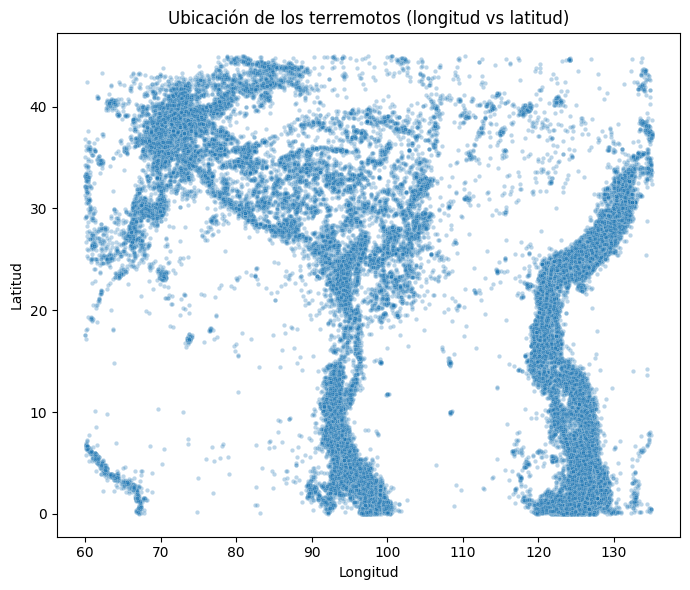

In [141]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=data_final, x="longitude", y="latitude", alpha=0.3, s=10)
plt.title("Ubicación de los terremotos (longitud vs latitud)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()


El gráfico muestra que los eventos se concentran en una franja específica de latitud y longitud. No hay terremotos distribuidos de forma uniforme, sino claramente agrupados en ciertos corredores geográficos donde la actividad sísmica es más frecuente.

Zonas con mas terremotos

In [142]:
data_analisis = data_final

In [143]:
# latitud y longitud redondeadas a grados
data_analisis["lat_round"] = data_analisis["latitude"].round(0)
data_analisis["lon_round"] = data_analisis["longitude"].round(0)

zona_counts = (data_analisis.groupby(["lat_round", "lon_round"]).size().reset_index(name="n_eventos").sort_values("n_eventos", ascending=False))

zona_counts.head(10)


,lat_round,lon_round,n_eventos
1416,36.0,71.0,2290
768,24.0,122.0,2048
1478,37.0,71.0,2041
103,2.0,127.0,1900
60,1.0,126.0,1382
363,10.0,126.0,1374
182,4.0,127.0,1294
43,1.0,97.0,1250
144,3.0,127.0,1245
304,8.0,94.0,1083


Al agrupar la latitud y longitud por grados, se observa que no hay diferencias grandes, talvez relacionado por ser corredores (como se vió en el anterior gráfico)

**Es importante verificar el conteo por años y meses**

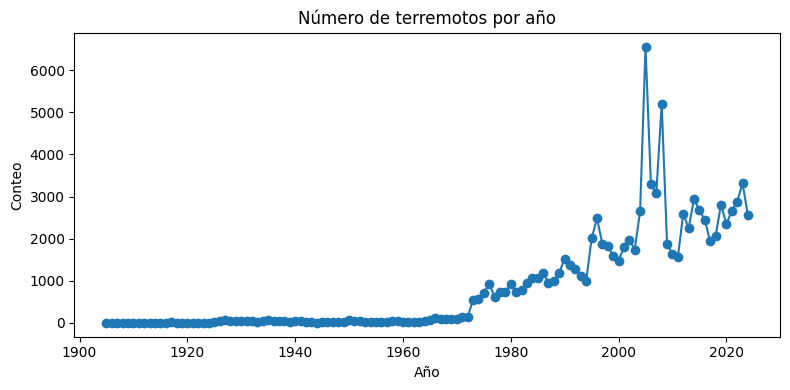

,year,n_eventos
110,2015,2676
111,2016,2447
112,2017,1934
113,2018,2063
114,2019,2812
115,2020,2345
116,2021,2657
117,2022,2879
118,2023,3317
119,2024,2553


In [144]:
eventos_por_year = (data_analisis.groupby("year").size().reset_index(name="n_eventos").sort_values("year"))

plt.figure(figsize=(8, 4))
plt.plot(eventos_por_year["year"], eventos_por_year["n_eventos"], marker="o")
plt.title("Número de terremotos por año")
plt.xlabel("Año")
plt.ylabel("Conteo")
plt.tight_layout()
plt.show()

eventos_por_year.tail(10) # los ultimos años


El conteo por año muestra cómo varía la cantidad de sismos a lo largo del tiempo. Se observan periodos con más registros y otros con menos, lo que puede reflejar tanto cambios reales en la actividad sísmica como cambios en la capacidad de detección y registro

**Conteo por meses**

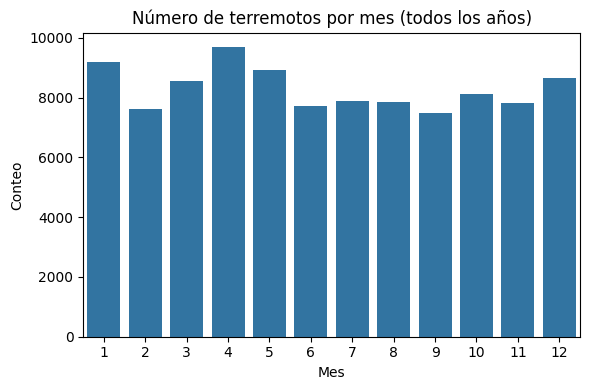

,month,n_eventos
0,1,9186
1,2,7620
2,3,8558
3,4,9683
4,5,8931
5,6,7716
6,7,7875
7,8,7855
8,9,7480
9,10,8134


In [145]:
eventos_por_mes = (data_analisis.groupby("month").size().reset_index(name="n_eventos").sort_values("month"))

plt.figure(figsize=(6, 4))
sns.barplot(data=eventos_por_mes, x="month", y="n_eventos")
plt.title("Número de terremotos por mes (todos los años)")
plt.xlabel("Mes")
plt.ylabel("Conteo")
plt.tight_layout()
plt.show()

eventos_por_mes


La distribución mensual no muestra un patrón estacional muy marcado: algunos meses tienen más eventos que otros, pero las diferencias no son extremas. Esto sugiere que, a escala mensual, la ocurrencia de terremotos en la región no está fuertemente ligada a una estación del año concreta.

Verificando distribucion de profundidad

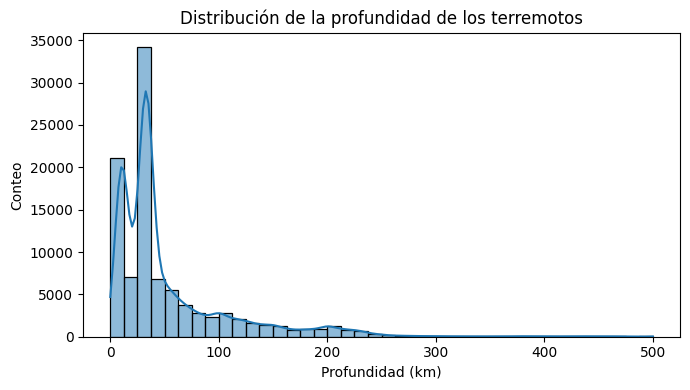

count    99506.000000
mean        54.715414
std         59.366698
min          0.000000
25%         19.000000
50%         33.000000
75%         62.735000
max        500.000000
Name: depth, dtype: float64

In [146]:
plt.figure(figsize=(7, 4))
sns.histplot(data=data_analisis, x="depth", bins=40, kde=True)
plt.title("Distribución de la profundidad de los terremotos")
plt.xlabel("Profundidad (km)")
plt.ylabel("Conteo")
plt.tight_layout()
plt.show()

data_analisis["depth"].describe()


La mayoría de los terremotos se concentran en profundidades relativamente pequeñas (sismos superficiales), con una cola hacia valores mayores que representan eventos intermedios o profundos. Es decir, los sismos más comunes son los poco profundos, aunque también existen algunos a mayor profundidad.

Distribucion de magnitud

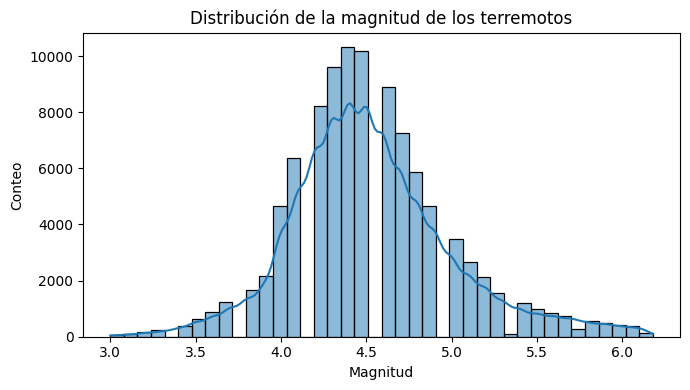

count    99506.000000
mean         4.528686
std          0.476970
min          3.000000
25%          4.200000
50%          4.500000
75%          4.800000
max          6.180000
Name: mag, dtype: float64

In [147]:
plt.figure(figsize=(7, 4))
sns.histplot(data=data_analisis, x="mag", bins=40, kde=True)
plt.title("Distribución de la magnitud de los terremotos")
plt.xlabel("Magnitud")
plt.ylabel("Conteo")
plt.tight_layout()
plt.show()

data_analisis["mag"].describe()


La mayoría de los eventos tienen magnitudes bajas o intermedias, mientras que los terremotos de gran magnitud son menos frecuentes. Esto es consistente con la estadística sísmica típica, donde los sismos pequeños son mucho más frecuentes que los grandes.

Ahora hagamos un conteo por tipo de magnitud

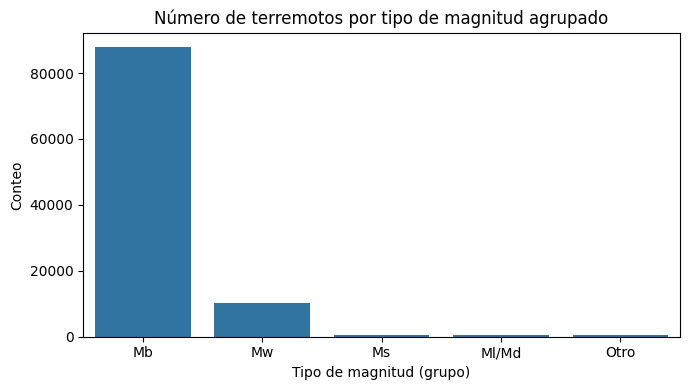

,magType_group,n_eventos
0,Mb,87805
3,Mw,10198
2,Ms,579
1,Ml/Md,500
4,Otro,424


In [148]:
magtype_counts = (data_analisis.groupby("magType_group").size().reset_index(name="n_eventos").sort_values("n_eventos", ascending=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=magtype_counts, x="magType_group", y="n_eventos")
plt.title("Número de terremotos por tipo de magnitud agrupado")
plt.xlabel("Tipo de magnitud (grupo)")
plt.ylabel("Conteo")
plt.tight_layout()
plt.show()

magtype_counts


El conteo por magType_group indica que la mayoría de los eventos se miden con uno o dos tipos de magnitud dominantes, por ejemplo, magnitud de momento Mw, mientras que otros grupos aparecen con menor frecuencia. Esto refleja las preferencias instrumentales y metodológicas de la red sismológica en la región.

Observemos la relacion magnitud con profundidad

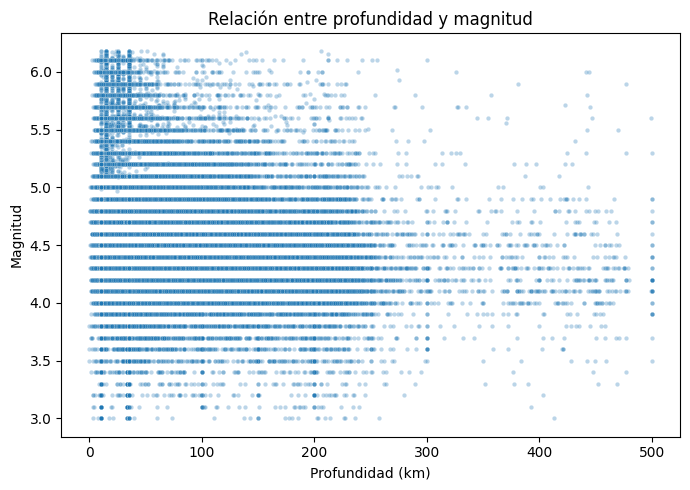

In [149]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data_analisis, x="depth", y="mag", alpha=0.3, s=10)
plt.title("Relación entre profundidad y magnitud")
plt.xlabel("Profundidad (km)")
plt.ylabel("Magnitud")
plt.tight_layout()
plt.show()


El diagrama de dispersión no muestra una relación clara y fuerte entre profundidad y magnitud. Aunque pueden existir algunos patrones pequeños, por ejemplo, ciertos rangos de profundidad donde aparecen magnitudes algo mayores, en general las magnitudes se distribuyen en distintos niveles de profundidad sin una tendencia muy clara.

Finalmente correlaciones entre variables numericas

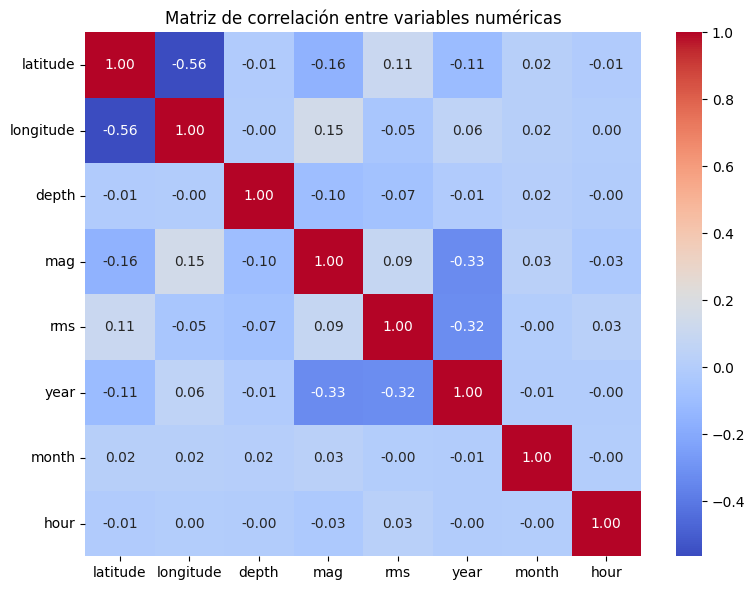

,latitude,longitude,depth,mag,rms,year,month,hour
latitude,1.000000,-0.563772,-0.009264,-0.160556,0.107813,-0.111602,0.016645,-0.011041
longitude,-0.563772,1.000000,-0.002353,0.146478,-0.047787,0.055870,0.018128,0.003218
depth,-0.009264,-0.002353,1.000000,-0.096485,-0.070260,-0.008568,0.015041,-0.002072
mag,-0.160556,0.146478,-0.096485,1.000000,0.089143,-0.327618,0.029284,-0.030317
rms,0.107813,-0.047787,-0.070260,0.089143,1.000000,-0.323347,-0.000280,0.027133
year,-0.111602,0.055870,-0.008568,-0.327618,-0.323347,1.000000,-0.007487,-0.003720
month,0.016645,0.018128,0.015041,0.029284,-0.000280,-0.007487,1.000000,-0.001363
hour,-0.011041,0.003218,-0.002072,-0.030317,0.027133,-0.003720,-0.001363,1.000000


In [150]:
num_cols = ["latitude", "longitude", "depth", "mag", "rms", "year", "month", "hour"]

corr_matrix = data_cleaned[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

corr_matrix


La matriz de correlación muestra que la mayoría de las variables numéricas tienen correlaciones moderadas o débiles entre sí. No se observa una correlación extremadamente alta entre magnitud y profundidad, ni entre magnitud y rms, lo que sugiere que estas características aportan información relativamente complementaria

### Conclusiones del análisis:  dónde y con qué características se generan los terremotos

A partir del conjunto de datos ya preprocesado (data_analisis), se puede concluir que:

- **Localización geográfica:**  
  Los terremotos no se distribuyen de forma uniforme, sino que se concentran en franjas y “bloques” específicos de latitud y longitud, lo que indica la presencia de zonas sísmicamente más activas asociadas a estructuras tectónicas particulares dentro de la región de estudio.

- **Evolución en el tiempo:**  
  El número de eventos por año varía a lo largo del tiempo, combinando posibles cambios reales en la actividad sísmica con mejoras en la detección y registro. En cuanto a los meses, no se observa una tendencia fuerte, por lo que la ocurrencia de sismos no parece estar ligada a una época del año concreta.

- **Profundidad y magnitud:**  
  La mayoría de los sismos son **poco profundos** y de **magnitud baja o moderada**, mientras que los eventos muy profundos o de gran magnitud son menos frecuentes pero están presentes. No se aprecia una relación muy marcada entre profundidad y magnitud, por lo que ambas dimensiones deben analizarse de forma complementaria.

- **Tipo de magnitud y calidad de los registros:**  
  La mayor parte de los terremotos se mide con unos pocos tipos de magnitud agrupados, por ejemplo, Mw, lo que simplifica el análisis al trabajar con magType_group. El filtrado previo de eventos poco representativos (tipos raros, estados automatic, etc...) permite centrarse en registros más relevantes.

En conjunto, las variables seleccionadas y transformadas permiten **describir patrones generales** sobre dónde se concentran los terremotos del catálogo y cuáles son sus características más frecuentes (profundidad, magnitud, tipo de magnitud y distribución temporal). 

Sin embargo, estos resultados se deben interpretar con cautela, ya que:
- El análisis se centra en un subconjunto de datos tras la imputación de rms y la eliminación de ciertos outliers  
- La base de datos refleja tanto la actividad sísmica real como las limitaciones e inconsistencias del sistema de registro.

Por lo tanto, más que ofrecer una explicación definitiva de las causas de los terremotos, este estudio proporciona una **descripcion estadística** de los sismos típicos presentes en el conjunto de datos estudiado.
